Khởi tạo dữ liệu và Vector Database

In [1]:
import pandas as pd
import chromadb
import time
import json
import numpy as np
from chromadb.utils import embedding_functions

# 1. Load Ground Truth
gt_df = pd.read_excel(r'G:\Khoa_Luan\Source_code\backend\chunking\IUH_Retrival_Chatbot_GroundTruth.xlsx')
print(f"Đã tải {len(gt_df)} câu hỏi kiểm thử.")

# 2. Kết nối ChromaDB (Cho luồng Vector)
chroma_client = chromadb.PersistentClient(path=r"G:\Khoa_Luan\Source_code\data\chroma_db") 
emb_fn = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
) 
collection = chroma_client.get_collection(name="camnang_iuh_collection", embedding_function=emb_fn)
print("Khởi tạo ChromaDB (Vector) thành công!")

Đã tải 28 câu hỏi kiểm thử.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Khởi tạo ChromaDB (Vector) thành công!


Nạp dữ liệu cho Keyword Search và Khởi tạo Re-ranker

In [2]:
from rank_bm25 import BM25Okapi
from sentence_transformers import CrossEncoder

# 1. Khởi tạo BM25 (Luồng Keyword)
print("Đang nạp dữ liệu từ DB để xây dựng BM25 Index...")
all_data = collection.get(include=['documents', 'metadatas'])
corpus_chunks = all_data['documents']
corpus_urls = [m.get('source', '') for m in all_data['metadatas']]

# Tách từ cơ bản
tokenized_corpus = [doc.lower().split(" ") for doc in corpus_chunks]
bm25 = BM25Okapi(tokenized_corpus)
print(f"BM25 đã nạp xong {len(corpus_chunks)} chunks.")

# 2. Khởi tạo BGE Reranker (Lọc nhiễu)
print("Đang tải BGE Reranker...")
local_reranker = CrossEncoder('BAAI/bge-reranker-v2-m3')
print("BGE Reranker sẵn sàng!")

Đang nạp dữ liệu từ DB để xây dựng BM25 Index...
BM25 đã nạp xong 518 chunks.
Đang tải BGE Reranker...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

BGE Reranker sẵn sàng!


Xây dựng các hàm lõi (Gộp RRF và Lọc BGE)

In [3]:
def rrf_merge(list1_chunks, list1_urls, list2_chunks, list2_urls, k=60):
    """Gộp 2 danh sách bằng thuật toán Reciprocal Rank Fusion."""
    rrf_scores = {}
    chunk_to_url = {}
    
    def compute_rrf(chunks, urls):
        for rank, (chunk, url) in enumerate(zip(chunks, urls)):
            if chunk not in rrf_scores:
                rrf_scores[chunk] = 0
                chunk_to_url[chunk] = url
            rrf_scores[chunk] += 1 / (k + rank + 1)
            
    compute_rrf(list1_chunks, list1_urls)
    compute_rrf(list2_chunks, list2_urls)
    # Xếp hạng lại theo điểm RRF
    sorted_items = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    return [item[0] for item in sorted_items], [chunk_to_url[item[0]] for item in sorted_items]

def local_rerank(query, documents, urls, top_n=3):
    """Lọc nhiễu và chấm điểm lại bằng Cross-Encoder."""
    if not documents: return [], []
    pairs = [[query, doc] for doc in documents]
    scores = local_reranker.predict(pairs)
    scored_docs = sorted(list(zip(scores, documents, urls)), key=lambda x: x[0], reverse=True)
    return [doc for score, doc, url in scored_docs[:top_n]], [url for score, doc, url in scored_docs[:top_n]]

Xây dựng 4 luồng chiến lược để So sánh

In [4]:
# 1. BASELINE 1: Chỉ dùng Vector
def b1_vector(query, k=3):
    start = time.time()
    res = collection.query(query_texts=[query], n_results=k)
    return {"urls": [m.get('source', '') for m in res['metadatas'][0]], "latency": time.time() - start}

# 2. BASELINE 2: Chỉ dùng Keyword (BM25)
def b2_keyword(query, k=3):
    start = time.time()
    tok_query = query.lower().split(" ")
    top_idx = np.argsort(bm25.get_scores(tok_query))[::-1][:k]
    return {"urls": [corpus_urls[i] for i in top_idx], "latency": time.time() - start}

# 3. BASELINE 3: Hybrid Thuần (Chỉ gộp, KHÔNG lọc nhiễu)
def b3_hybrid_no_rerank(query, k=3):
    start = time.time()
    v_res = collection.query(query_texts=[query], n_results=10)
    v_urls = [m.get('source', '') for m in v_res['metadatas'][0]]
    v_chunks = v_res['documents'][0]
    
    tok_query = query.lower().split(" ")
    top_idx = np.argsort(bm25.get_scores(tok_query))[::-1][:10]
    k_urls = [corpus_urls[i] for i in top_idx]
    k_chunks = [corpus_chunks[i] for i in top_idx]
    
    m_chunks, m_urls = rrf_merge(v_chunks, v_urls, k_chunks, k_urls)
    return {"urls": m_urls[:k], "latency": time.time() - start}

# 4. BASELINE 4: Hybrid Tối ưu (Gộp + Lọc nhiễu Reranker)
def b4_hybrid_rerank(query, k_initial=15, k_final=3):
    start = time.time()
    v_res = collection.query(query_texts=[query], n_results=k_initial)
    v_urls = [m.get('source', '') for m in v_res['metadatas'][0]]
    v_chunks = v_res['documents'][0]
    
    tok_query = query.lower().split(" ")
    top_idx = np.argsort(bm25.get_scores(tok_query))[::-1][:k_initial]
    k_urls = [corpus_urls[i] for i in top_idx]
    k_chunks = [corpus_chunks[i] for i in top_idx]
    
    m_chunks, m_urls = rrf_merge(v_chunks, v_urls, k_chunks, k_urls)
    f_chunks, f_urls = local_rerank(query, m_chunks, m_urls, top_n=k_final)
    
    return {"urls": f_urls, "latency": time.time() - start}

In [5]:
evaluation_logs = []

print("BẮT ĐẦU CHẠY KIỂM THỬ 4 CHIẾN LƯỢC ĐỐI CHỨNG...")
for index, row in gt_df.iterrows():
    query = row['Query']
    true_tier = row['Tier']
    expected_urls = row['Expected_Source_URLs']
    
    print(f"Đang xử lý [{index+1}/{len(gt_df)}] (Tier {true_tier}): {query[:40]}...")
    
    # Chạy 4 Baselines
    res_1 = b1_vector(query)
    res_2 = b2_keyword(query)
    res_3 = b3_hybrid_no_rerank(query)
    res_4 = b4_hybrid_rerank(query)
    
    log_entry = {
        "query_id": index + 1,
        "true_tier": true_tier,
        "expected_urls": expected_urls,
        "b1": res_1, "b2": res_2, "b3": res_3, "b4": res_4
    }
    evaluation_logs.append(log_entry)

with open('retrieval_experiment_logs_V3.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_logs, f, ensure_ascii=False, indent=4)

print("HOÀN TẤT! Đã lưu log.")

BẮT ĐẦU CHẠY KIỂM THỬ 4 CHIẾN LƯỢC ĐỐI CHỨNG...
Đang xử lý [1/28] (Tier 1): Trường Đại học Công nghiệp TP.HCM có nhữ...
Đang xử lý [2/28] (Tier 1): Điểm TOEIC 4 kỹ năng tối thiểu là bao nh...
Đang xử lý [3/28] (Tier 1): Tài khoản Microsoft của sinh viên được y...
Đang xử lý [4/28] (Tier 1): Học kỳ đầu tiên tân sinh viên có phải tự...
Đang xử lý [5/28] (Tier 1): Các ngân hàng nào hỗ trợ nộp học phí qua...
Đang xử lý [6/28] (Tier 1): Để nhận học bổng doanh nghiệp, sinh viên...
Đang xử lý [7/28] (Tier 1): Cơ sở chính của trường được đặt tại địa ...
Đang xử lý [8/28] (Tier 1): Phòng Công tác chính trị và Hỗ trợ sinh ...
Đang xử lý [9/28] (Tier 2): Sinh viên sẽ bị xử lý như thế nào nếu nộ...
Đang xử lý [10/28] (Tier 2): Để được xét tốt nghiệp, sinh viên cần tí...
Đang xử lý [11/28] (Tier 2): Sự khác biệt giữa mức học bổng của sinh ...
Đang xử lý [12/28] (Tier 2): Sinh viên bị cảnh báo kết quả học tập tr...
Đang xử lý [13/28] (Tier 2): Những nguyên nhân nào dẫn đến việc sinh ...
Đang xử lý [

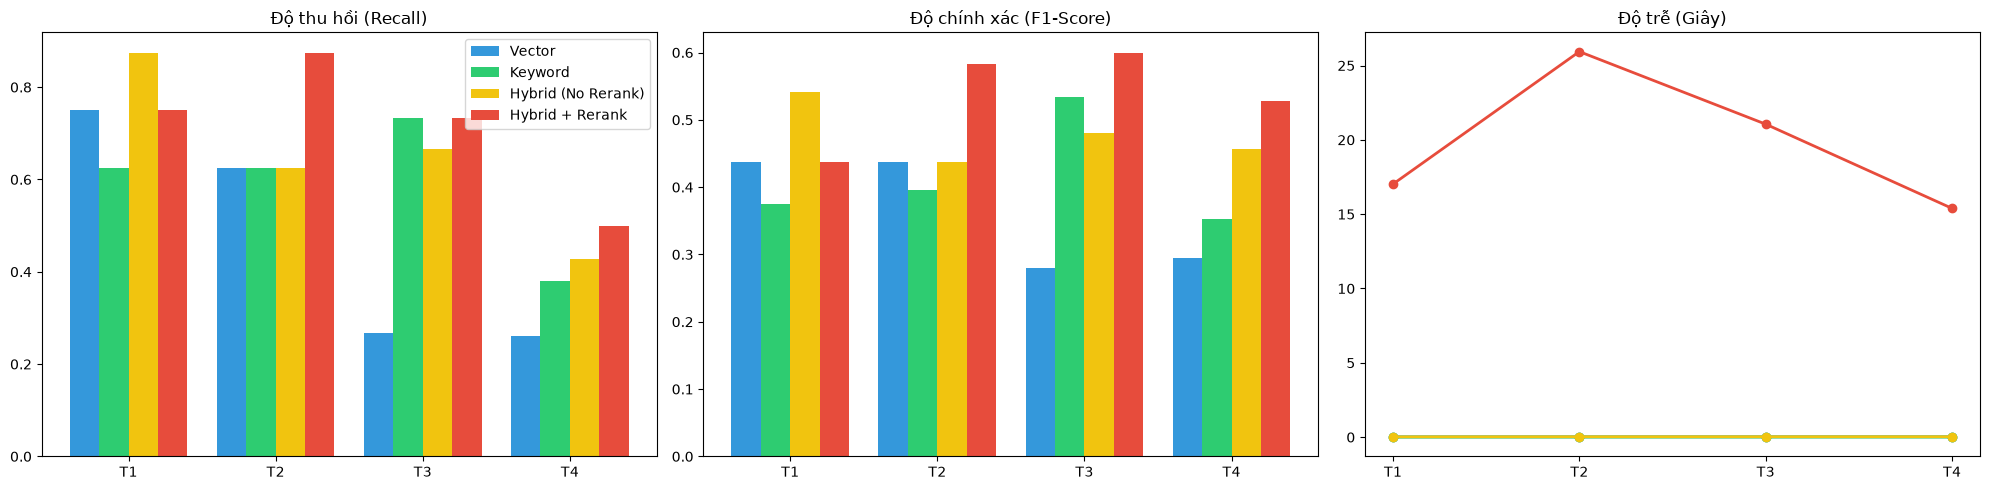

,Metric,Vector,Keyword,Hybrid (No Rerank),Hybrid + Rerank
0,Recall,0.506,0.583,0.655,0.720
1,F1-Score,0.374,0.404,0.480,0.531
2,Latency(s),0.026,0.004,0.027,19.881


In [7]:
import matplotlib.pyplot as plt

with open('retrieval_experiment_logs_V3.json', 'r', encoding='utf-8') as f:
    logs = json.load(f)

def calc_metrics(exp_str, ret_list):
    exp_set = set([url.strip() for url in str(exp_str).split(',')])
    ret_set = set([url.strip() for url in ret_list])
    tp = len(exp_set.intersection(ret_set))
    fp = len(ret_set - exp_set)
    fn = len(exp_set - ret_set)
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
    return r, f1

results = []
for log in logs:
    exp = log['expected_urls']
    b1_r, b1_f1 = calc_metrics(exp, log['b1']['urls'])
    b2_r, b2_f1 = calc_metrics(exp, log['b2']['urls'])
    b3_r, b3_f1 = calc_metrics(exp, log['b3']['urls'])
    b4_r, b4_f1 = calc_metrics(exp, log['b4']['urls'])
    
    results.append({
        'Tier': log['true_tier'],
        'B1_R': b1_r, 'B1_F1': b1_f1, 'B1_Lat': log['b1']['latency'],
        'B2_R': b2_r, 'B2_F1': b2_f1, 'B2_Lat': log['b2']['latency'],
        'B3_R': b3_r, 'B3_F1': b3_f1, 'B3_Lat': log['b3']['latency'],
        'B4_R': b4_r, 'B4_F1': b4_f1, 'B4_Lat': log['b4']['latency']
    })

df = pd.DataFrame(results)
summary = df.groupby('Tier').mean().reset_index()

# TRỰC QUAN HÓA
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
x = np.arange(len(summary['Tier']))
w = 0.2

c1, c2, c3, c4 = '#3498db', '#2ecc71', '#f1c40f', '#e74c3c'
labels = ['Vector', 'Keyword', 'Hybrid (No Rerank)', 'Hybrid + Rerank']

# Biểu đồ 1: Recall
for i, col in enumerate(['B1_R', 'B2_R', 'B3_R', 'B4_R']):
    axes[0].bar(x + (i-1.5)*w, summary[col], w, label=labels[i], color=[c1,c2,c3,c4][i])
axes[0].set_title('Độ thu hồi (Recall)'); axes[0].set_xticks(x); axes[0].set_xticklabels(['T1', 'T2', 'T3', 'T4']); axes[0].legend()

# Biểu đồ 2: F1-Score
for i, col in enumerate(['B1_F1', 'B2_F1', 'B3_F1', 'B4_F1']):
    axes[1].bar(x + (i-1.5)*w, summary[col], w, label=labels[i], color=[c1,c2,c3,c4][i])
axes[1].set_title('Độ chính xác (F1-Score)'); axes[1].set_xticks(x); axes[1].set_xticklabels(['T1', 'T2', 'T3', 'T4'])

# Biểu đồ 3: Latency
for i, col in enumerate(['B1_Lat', 'B2_Lat', 'B3_Lat', 'B4_Lat']):
    axes[2].plot(x, summary[col], marker='o', label=labels[i], color=[c1,c2,c3,c4][i], linewidth=2)
axes[2].set_title('Độ trễ (Giây)'); axes[2].set_xticks(x); axes[2].set_xticklabels(['T1', 'T2', 'T3', 'T4'])

plt.tight_layout()
plt.show()

# Hiển thị bảng tổng quát
overall = pd.DataFrame({
    'Metric': ['Recall', 'F1-Score', 'Latency(s)'],
    'Vector': [df['B1_R'].mean(), df['B1_F1'].mean(), df['B1_Lat'].mean()],
    'Keyword': [df['B2_R'].mean(), df['B2_F1'].mean(), df['B2_Lat'].mean()],
    'Hybrid (No Rerank)': [df['B3_R'].mean(), df['B3_F1'].mean(), df['B3_Lat'].mean()],
    'Hybrid + Rerank': [df['B4_R'].mean(), df['B4_F1'].mean(), df['B4_Lat'].mean()]
})
display(overall.round(3))